In [49]:
#!pip install ucimlrepo
import pandas as pd
import matplotlib.pyplot as plt

In [50]:
from ucimlrepo import fetch_ucirepo 
  
# Scarico dataset UCI (tutto il dataset)
tennis_major_tournament_match_statistics = fetch_ucirepo(id=300) 
  
# Features e target come DataFrame
X_row = tennis_major_tournament_match_statistics.data.features 
y_row = tennis_major_tournament_match_statistics.data.targets 

# Unisco in un unico dataframe (più comodo per EDA)
df = pd.concat([X_row, y_row], axis=1)

#print(X.head())
# metadata 
#print(tennis_major_tournament_match_statistics.metadata) 
  
# variable information 
 #print(tennis_major_tournament_match_statistics.variables) 


# Controlli base
print("Shape df:", df.shape)
print("\nColonne (prime 30):")
print(list(df.columns)[:30])

print("\nInfo:")
print(df.info())

Shape df: (943, 43)

Colonne (prime 30):
['Tournament', 'Player1', 'Player2', 'Round', 'FNL1', 'FNL2', 'FSP.1', 'FSW.1', 'SSP.1', 'SSW.1', 'ACE.1', 'DBF.1', 'WNR.1', 'UFE.1', 'BPC.1', 'BPW.1', 'NPA.1', 'NPW.1', 'TPW.1', 'ST1.1', 'ST2.1', 'ST3.1', 'ST4.1', 'ST5.1', 'FSP.2', 'FSW.2', 'SSP.2', 'SSW.2', 'ACE.2', 'DBF.2']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 943 entries, 0 to 942
Data columns (total 43 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Tournament  943 non-null    object 
 1   Player1     943 non-null    object 
 2   Player2     943 non-null    object 
 3   Round       943 non-null    int64  
 4   FNL1        942 non-null    float64
 5   FNL2        942 non-null    float64
 6   FSP.1       943 non-null    int64  
 7   FSW.1       943 non-null    int64  
 8   SSP.1       943 non-null    int64  
 9   SSW.1       943 non-null    int64  
 10  ACE.1       921 non-null    float64
 11  DBF.1       935 non-null    flo

In [51]:
print(y_row.columns)


Index(['Result'], dtype='object')


In [52]:
# Separiamo X e y
y = df["Result"]      # target
X = df.drop("Result", axis=1)

print(X.dtypes.value_counts())
print("Vecchia shape:", X.shape)

categorical_cols = X.select_dtypes(include="object").columns
print("Colonne categoriche: ", categorical_cols)

# decisione didattica eliminiamo le colonne categoriche
    # eliminiamo Player1 / Player2 perche cosi evitiamo il bias da identita. Voliamo che il modello impara statistiche e non che Federer = vittoria
    # eliminiamo Tournament perche voliamo modello basato su statistiche match e non su dove si è svolto. È una semplificazione didattica.
X = X.drop(categorical_cols, axis=1)
print("Nuova shape:", X.shape)



float64    30
int64       9
object      3
Name: count, dtype: int64
Vecchia shape: (943, 42)
Colonne categoriche:  Index(['Tournament', 'Player1', 'Player2'], dtype='object')
Nuova shape: (943, 39)


In [53]:
# Controllo missing values

print(X.isnull().sum().sort_values(ascending=False))


ST5.1    857
ST5.2    857
ST4.2    722
ST4.1    722
ST3.1    321
ST3.2    321
TPW.2    312
TPW.1    312
UFE.1    126
WNR.2    126
WNR.1    126
UFE.2    126
NPA.1     84
NPA.2     84
NPW.2     83
NPW.1     83
ACE.2     22
ACE.1     22
DBF.1      8
DBF.2      8
ST2.2      4
ST2.1      4
FNL1       1
BPW.2      1
ST1.2      1
ST1.1      1
BPC.2      1
BPW.1      1
FNL2       1
BPC.1      1
Round      0
SSW.1      0
SSP.1      0
FSW.1      0
FSP.1      0
FSW.2      0
FSP.2      0
SSW.2      0
SSP.2      0
dtype: int64


In [54]:
# Definiamo le colonne da eliminare (Data Leakage + Target)
colonne_da_eliminare = [
    'ST1.1', 'ST1.2',         # Game set 1
    'ST2.1', 'ST2.2',         # Game set 2
    'ST3.1', 'ST3.2',         # Game set 3
    'ST4.1', 'ST4.2',         # Game set 4 
    'ST5.1', 'ST5.2',         # Game set 5                             
    'TPW.1', 'TPW.2',         # Punti totali (troppo vicini al risultato)  leakage!!
    'FNL1',  'FNL2'           # Risultato finale set                       leakage!!
]
print("Vecchia shape:", X.shape)

# Usiamo errors='ignore' così se alcune le hai già tolte non si blocca
X = X.drop(colonne_da_eliminare, axis=1)

print("Features rimaste in X:")
print(X.columns.tolist())
print("Nuova shape:", X.shape)

Vecchia shape: (943, 39)
Features rimaste in X:
['Round', 'FSP.1', 'FSW.1', 'SSP.1', 'SSW.1', 'ACE.1', 'DBF.1', 'WNR.1', 'UFE.1', 'BPC.1', 'BPW.1', 'NPA.1', 'NPW.1', 'FSP.2', 'FSW.2', 'SSP.2', 'SSW.2', 'ACE.2', 'DBF.2', 'WNR.2', 'UFE.2', 'BPC.2', 'BPW.2', 'NPA.2', 'NPW.2']
Nuova shape: (943, 25)


In [55]:
# Media imputazione
for col in ["UFE.1","UFE.2","WNR.1","WNR.2",
            "NPA.1","NPA.2","NPW.1","NPW.2",
            "BPC.1","BPW.1","BPC.2","BPW.2"]:
    X[col] = X[col].fillna(X[col].mean())

# Zero imputazione
for col in ["ACE.1","ACE.2","DBF.1","DBF.2"]:
        X[col] = X[col].fillna(0)

print(X.isnull().sum())

Round    0
FSP.1    0
FSW.1    0
SSP.1    0
SSW.1    0
ACE.1    0
DBF.1    0
WNR.1    0
UFE.1    0
BPC.1    0
BPW.1    0
NPA.1    0
NPW.1    0
FSP.2    0
FSW.2    0
SSP.2    0
SSW.2    0
ACE.2    0
DBF.2    0
WNR.2    0
UFE.2    0
BPC.2    0
BPW.2    0
NPA.2    0
NPW.2    0
dtype: int64


In [56]:
import pandas as pd

df_plot = X.copy()
df_plot["Result"] = y


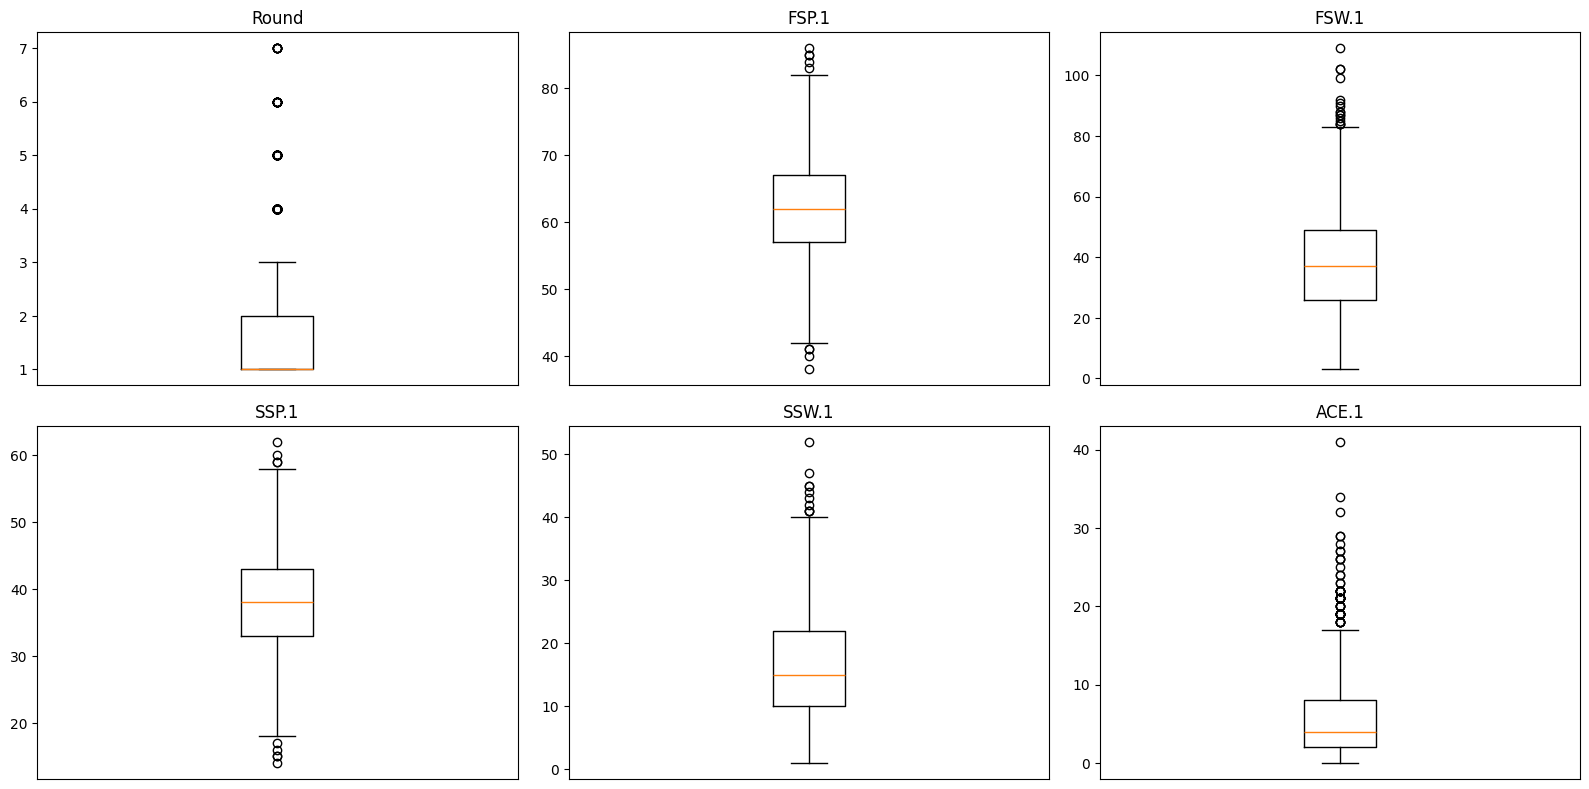

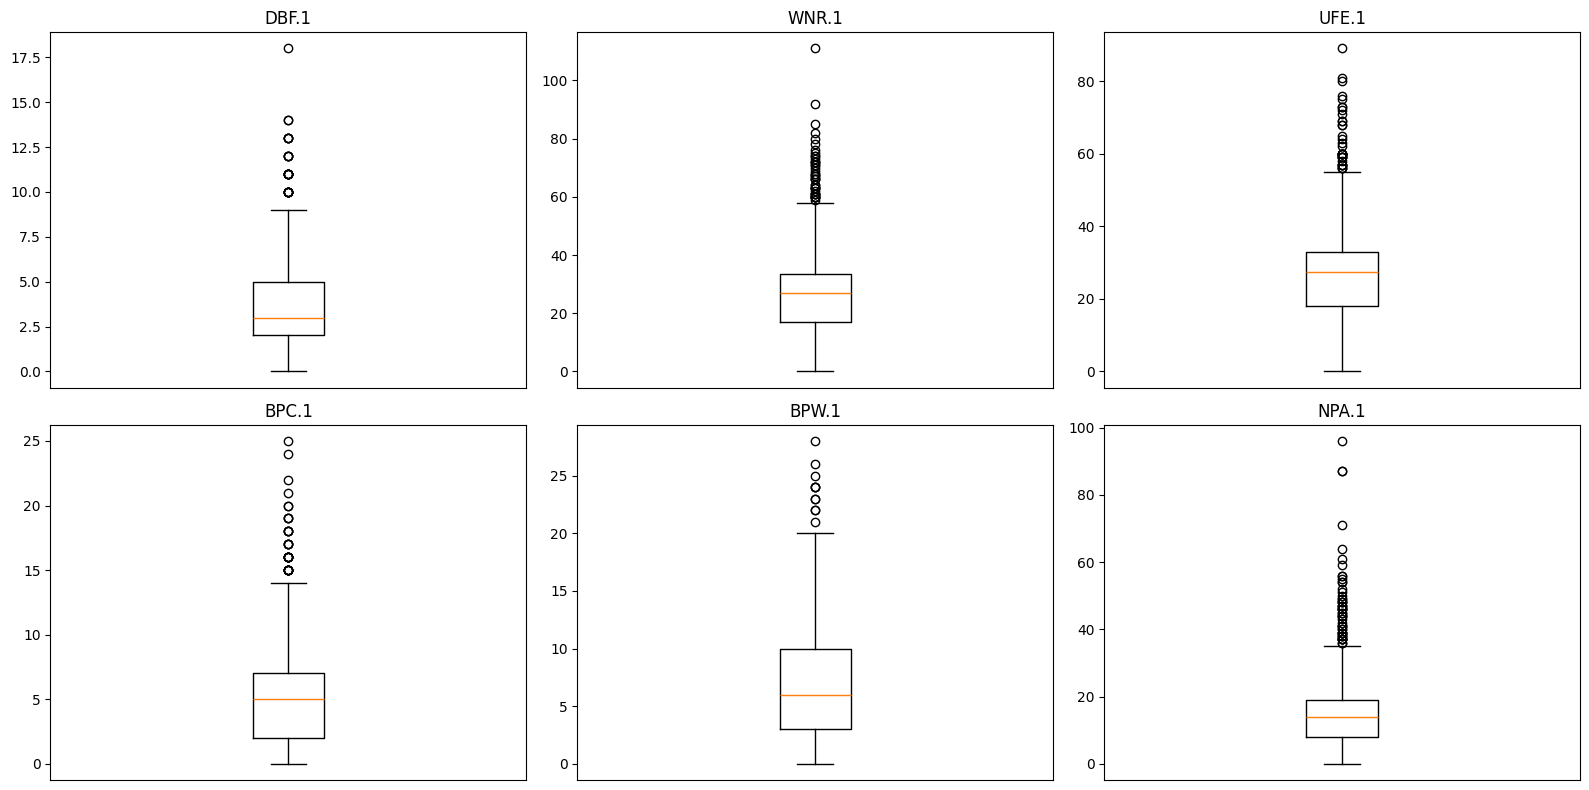

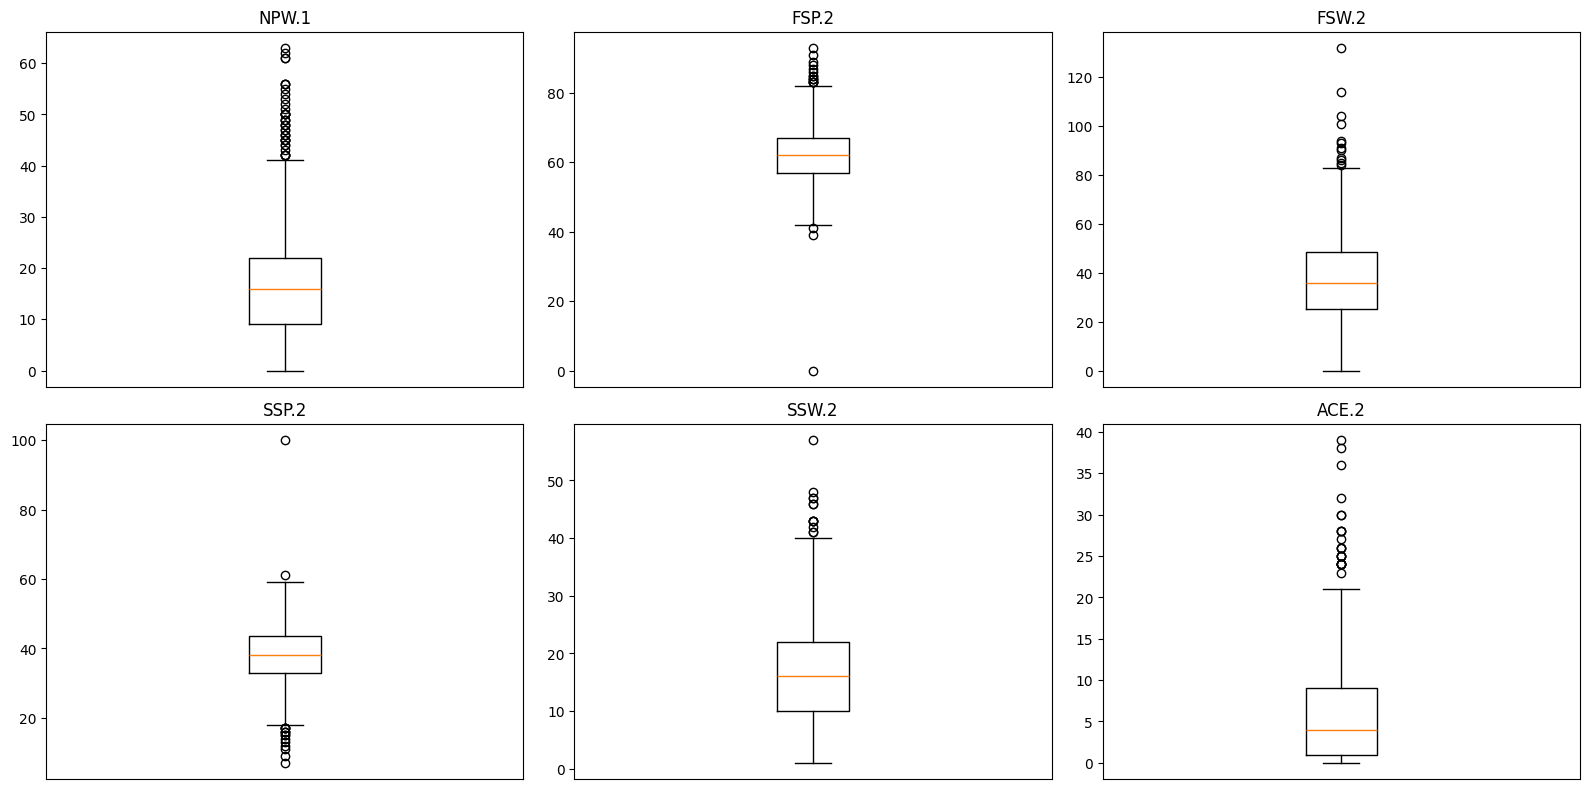

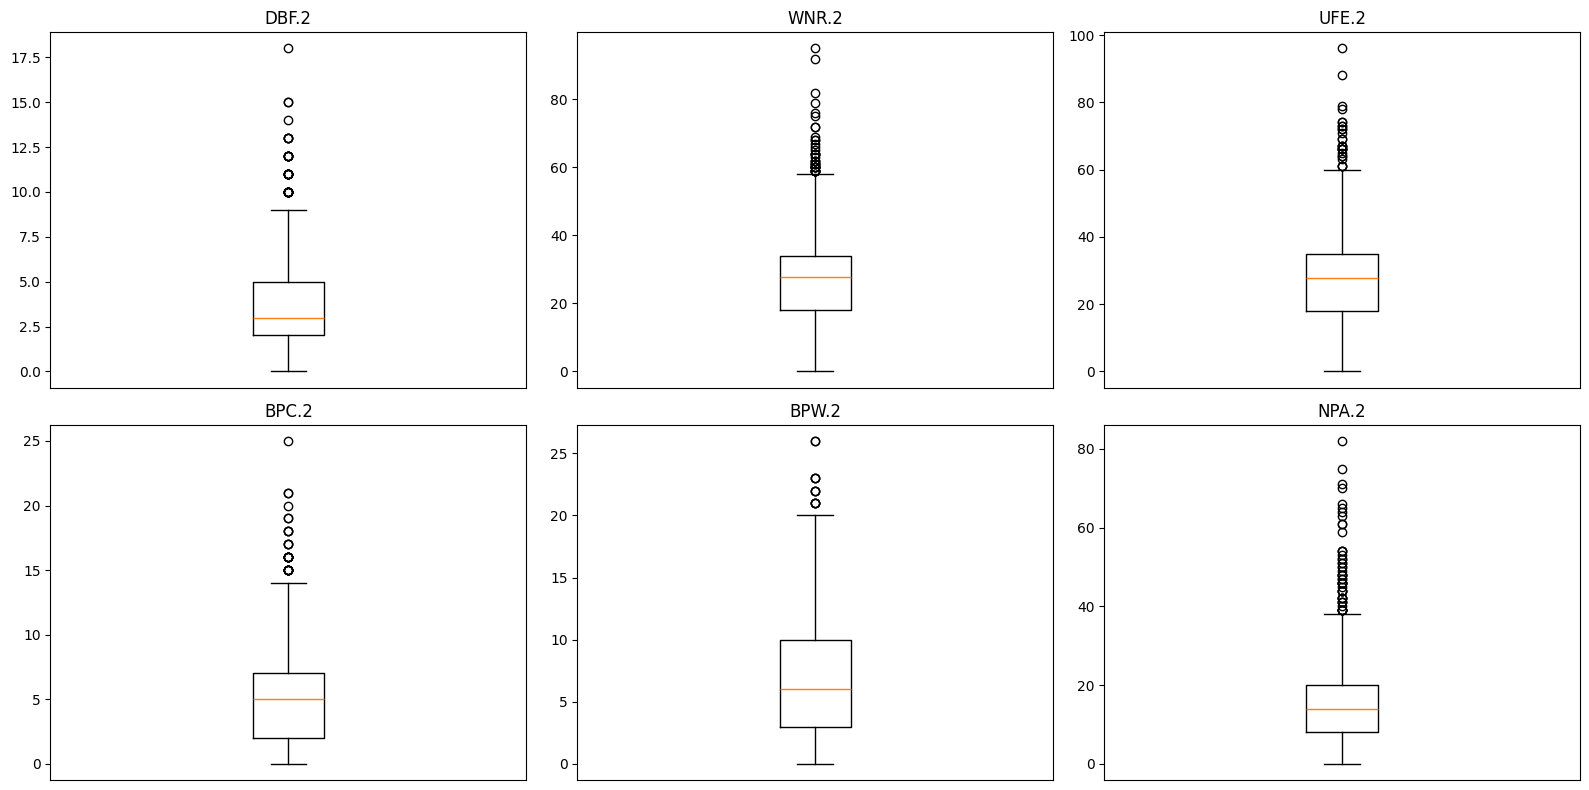

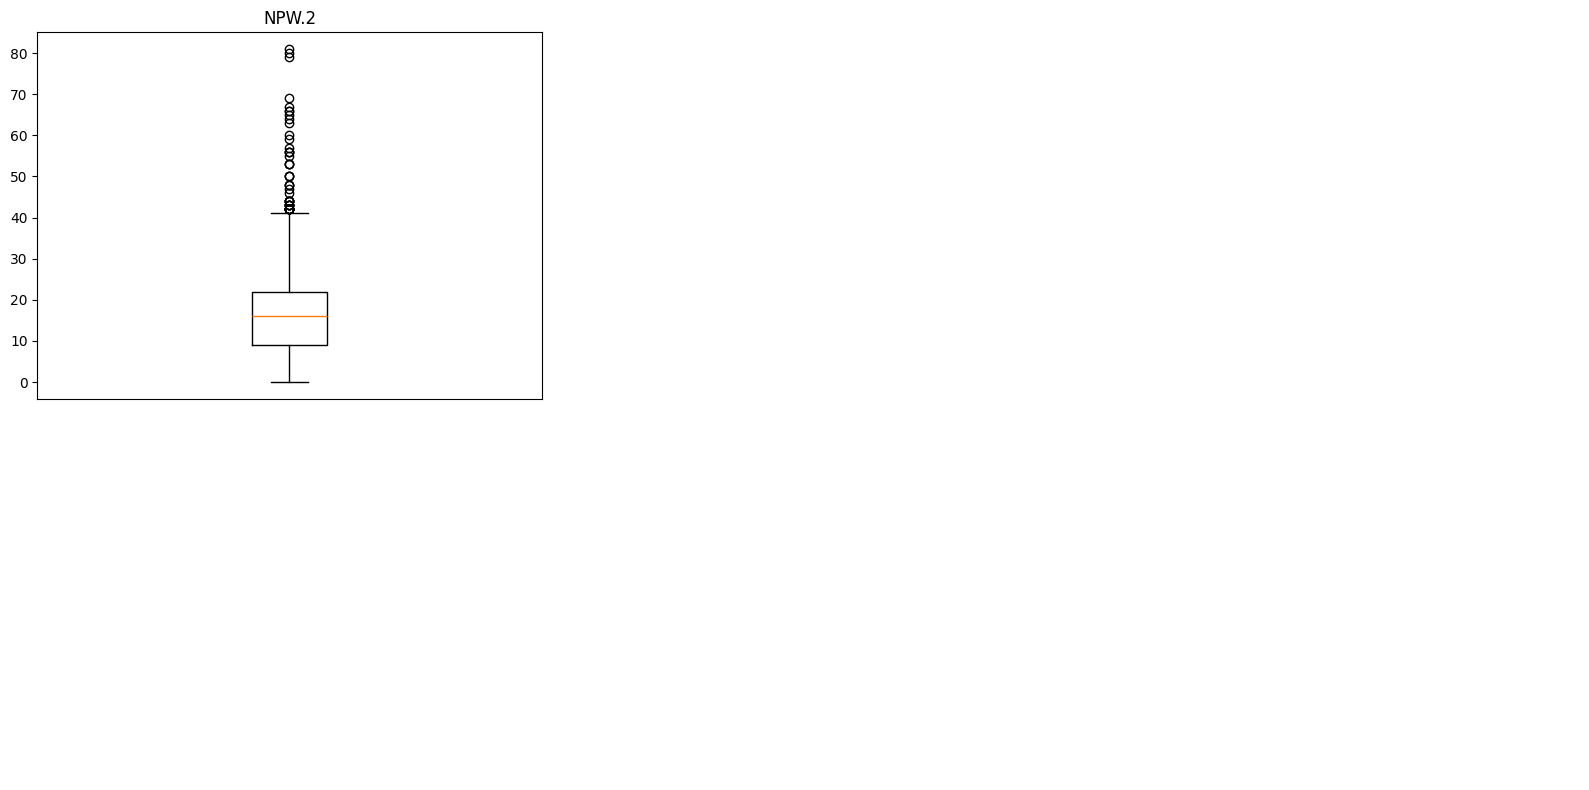

In [57]:
# Boxplot per ogni singola feature (uno alla volta)
import math
import matplotlib.pyplot as plt

cols = list(X.columns)

per_fig = 6   # quanti boxplot per figura
n_fig = math.ceil(len(cols) / per_fig)

for f in range(n_fig):

    subset = cols[f*per_fig:(f+1)*per_fig]

    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    axes = axes.ravel()

    for ax, col in zip(axes, subset):
        ax.boxplot(X[col].dropna())
        ax.set_title(col)
        ax.set_xticks([])

    # Se restano celle vuote → le spegniamo
    for ax in axes[len(subset):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()



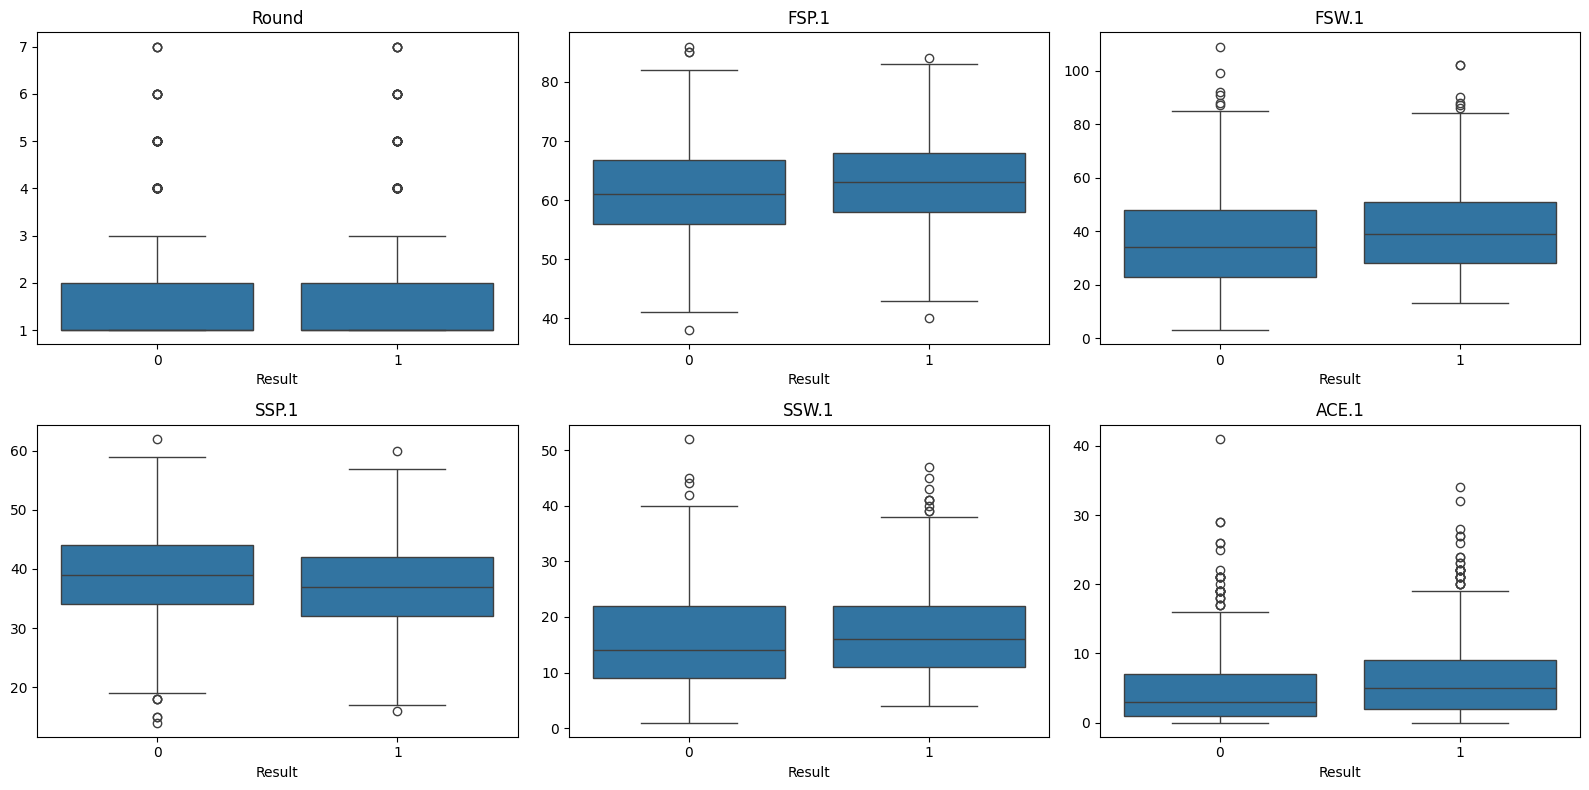

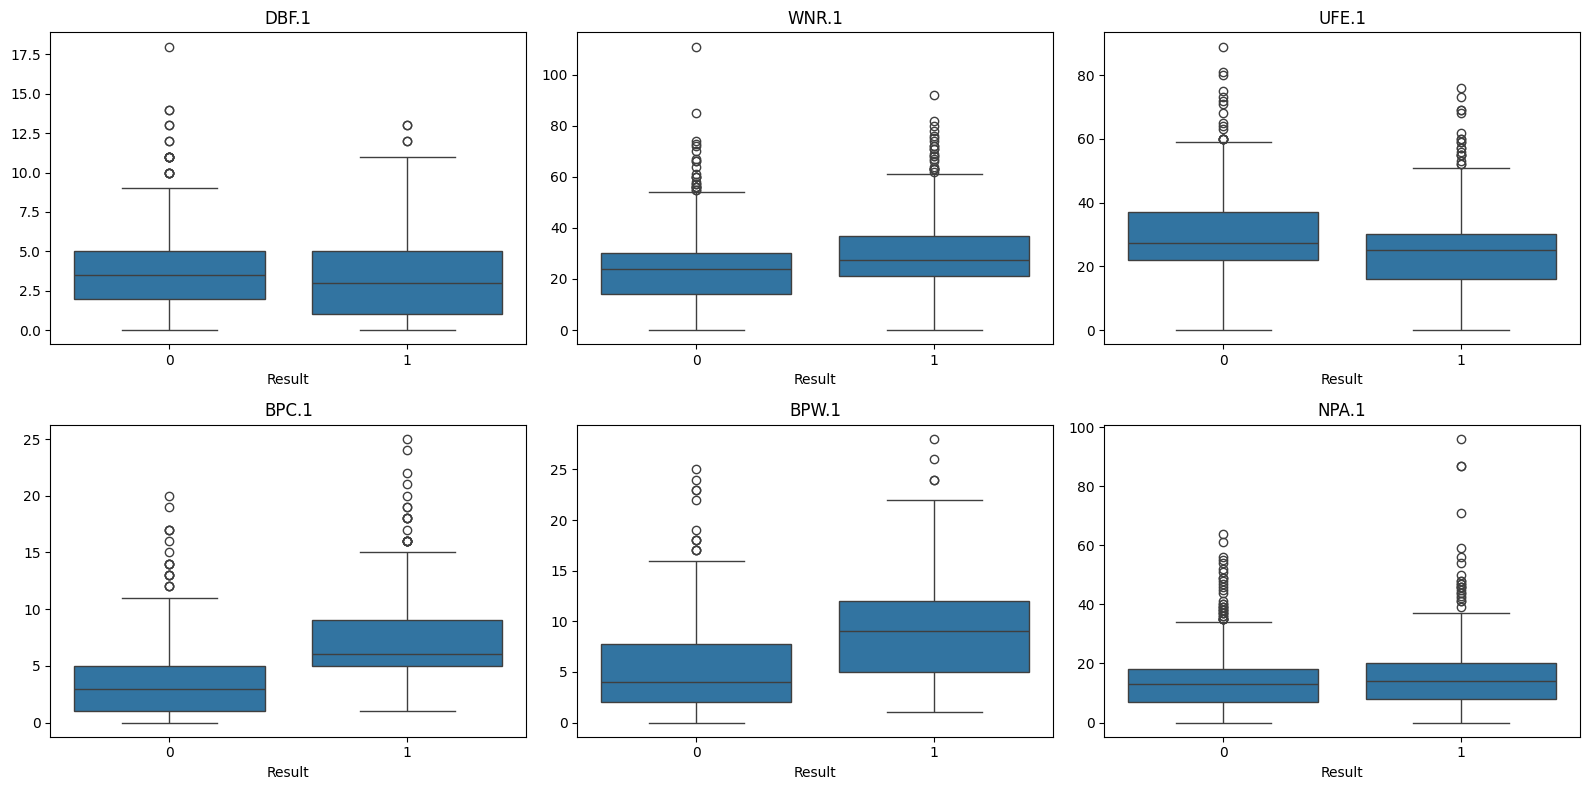

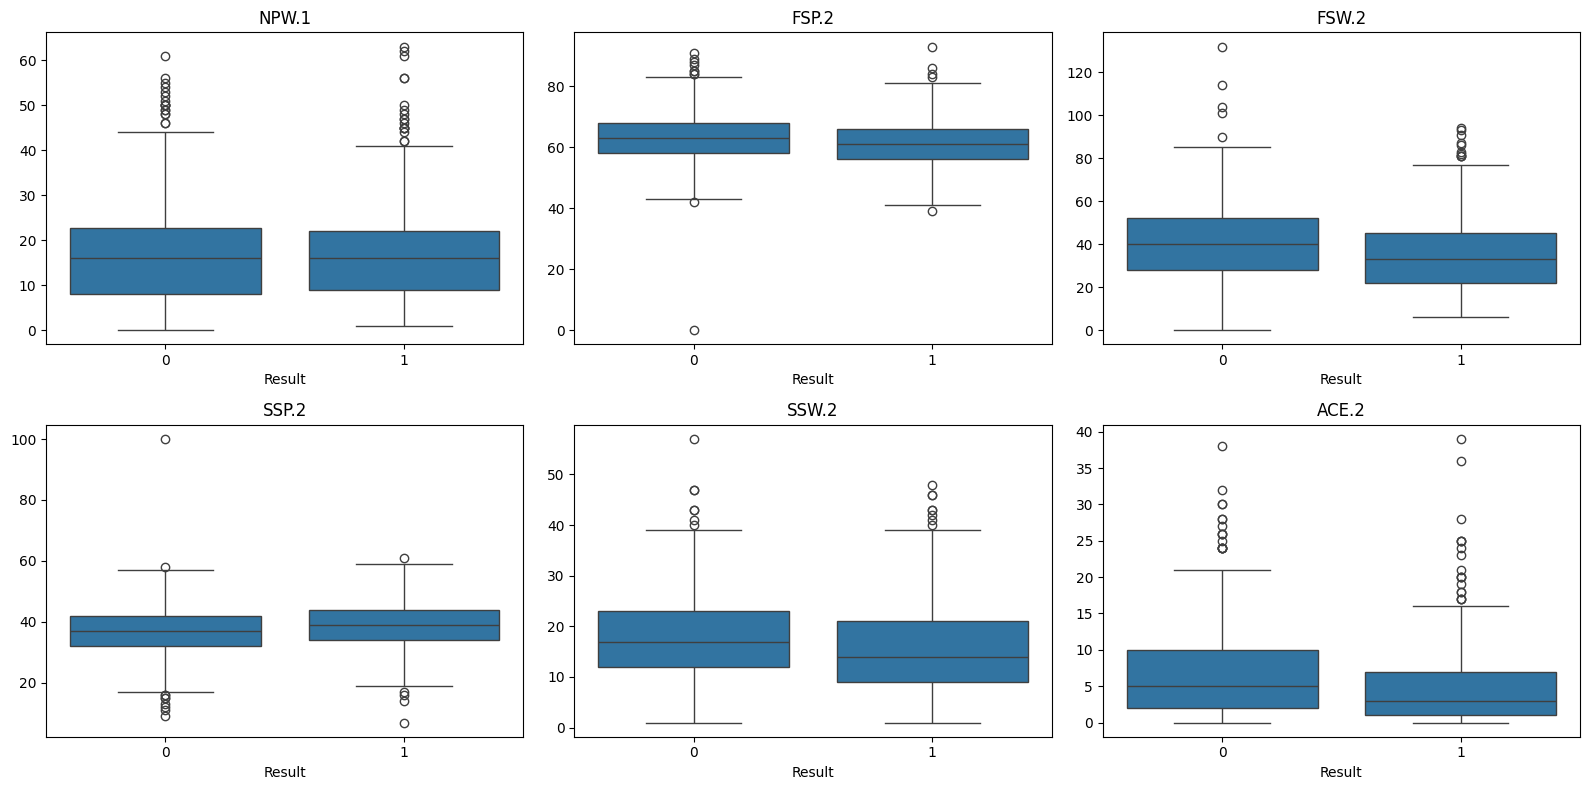

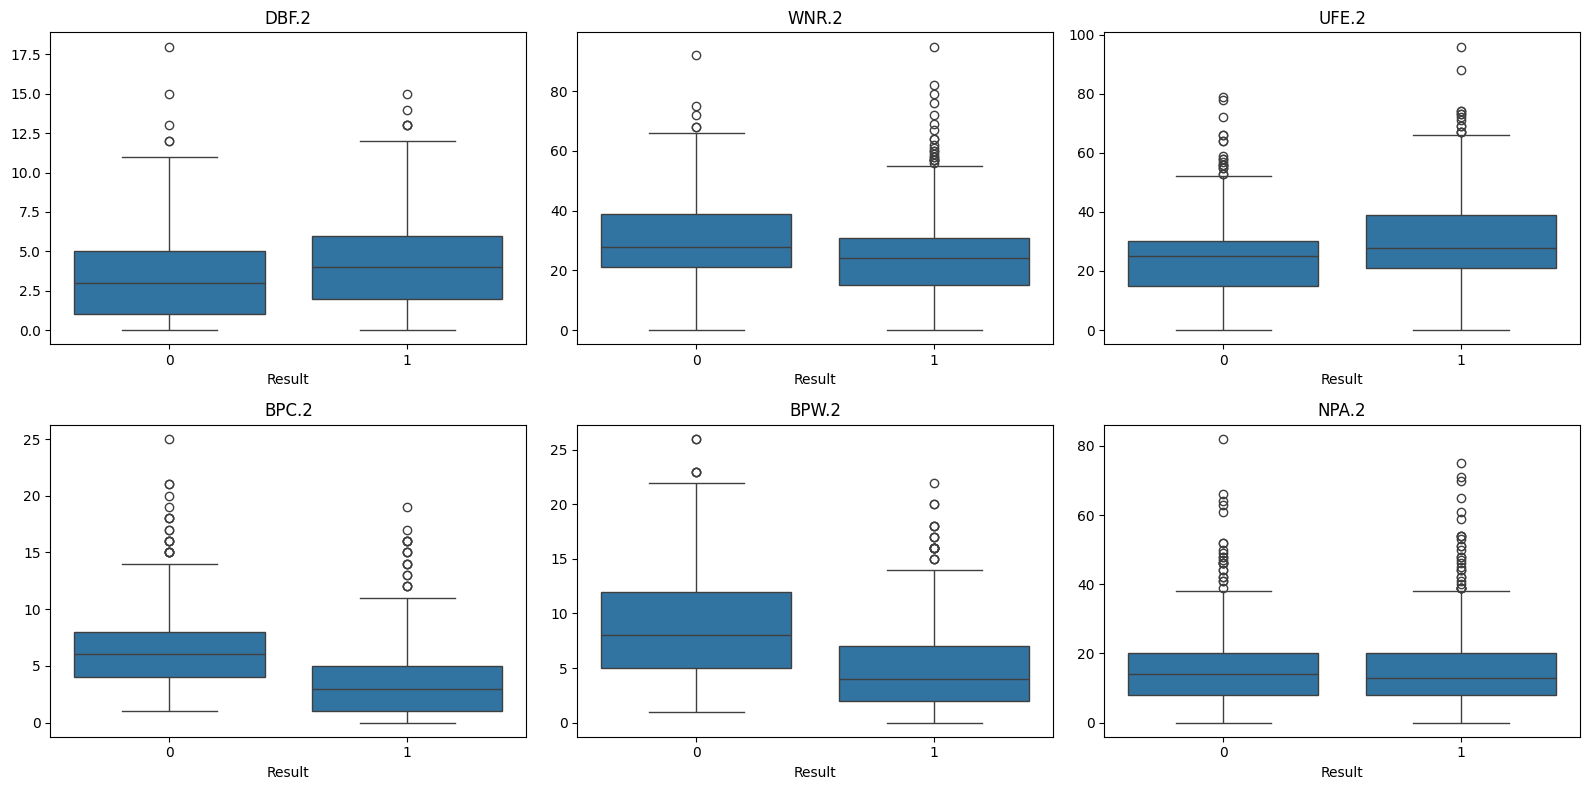

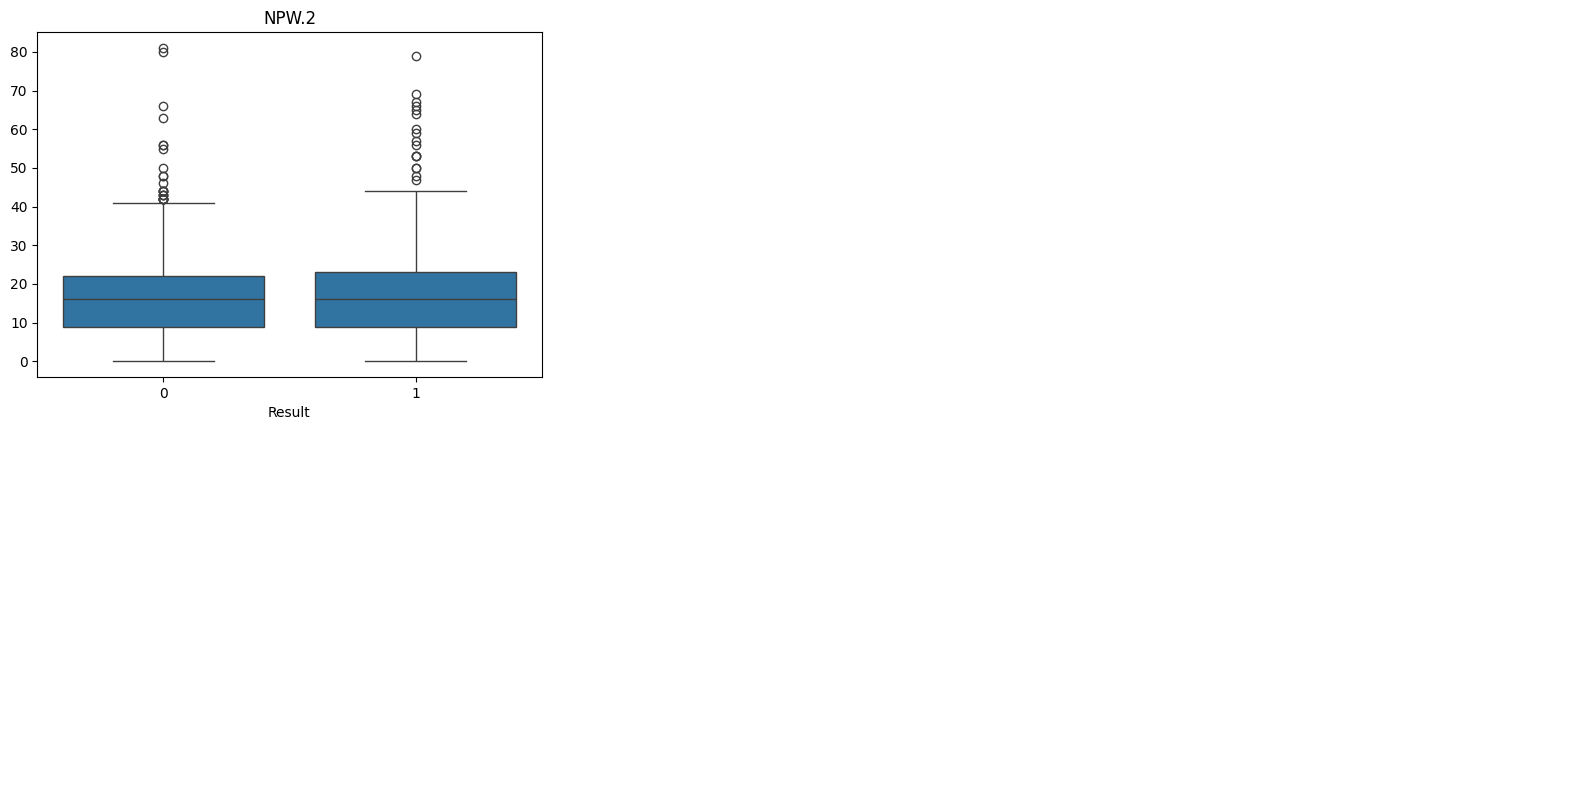

In [58]:
import math
import seaborn as sns
import matplotlib.pyplot as plt

cols = list(X.columns)
per_fig = 6
n_fig = math.ceil(len(cols) / per_fig)

for f in range(n_fig):
    subset = cols[f*per_fig:(f+1)*per_fig]
    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    axes = axes.ravel()

    for ax, col in zip(axes, subset):
        sns.boxplot(data=df_plot, x="Result", y=col, ax=ax)
        ax.set_title(col)
        ax.set_xlabel("Result")
        ax.set_ylabel("")

    for ax in axes[len(subset):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


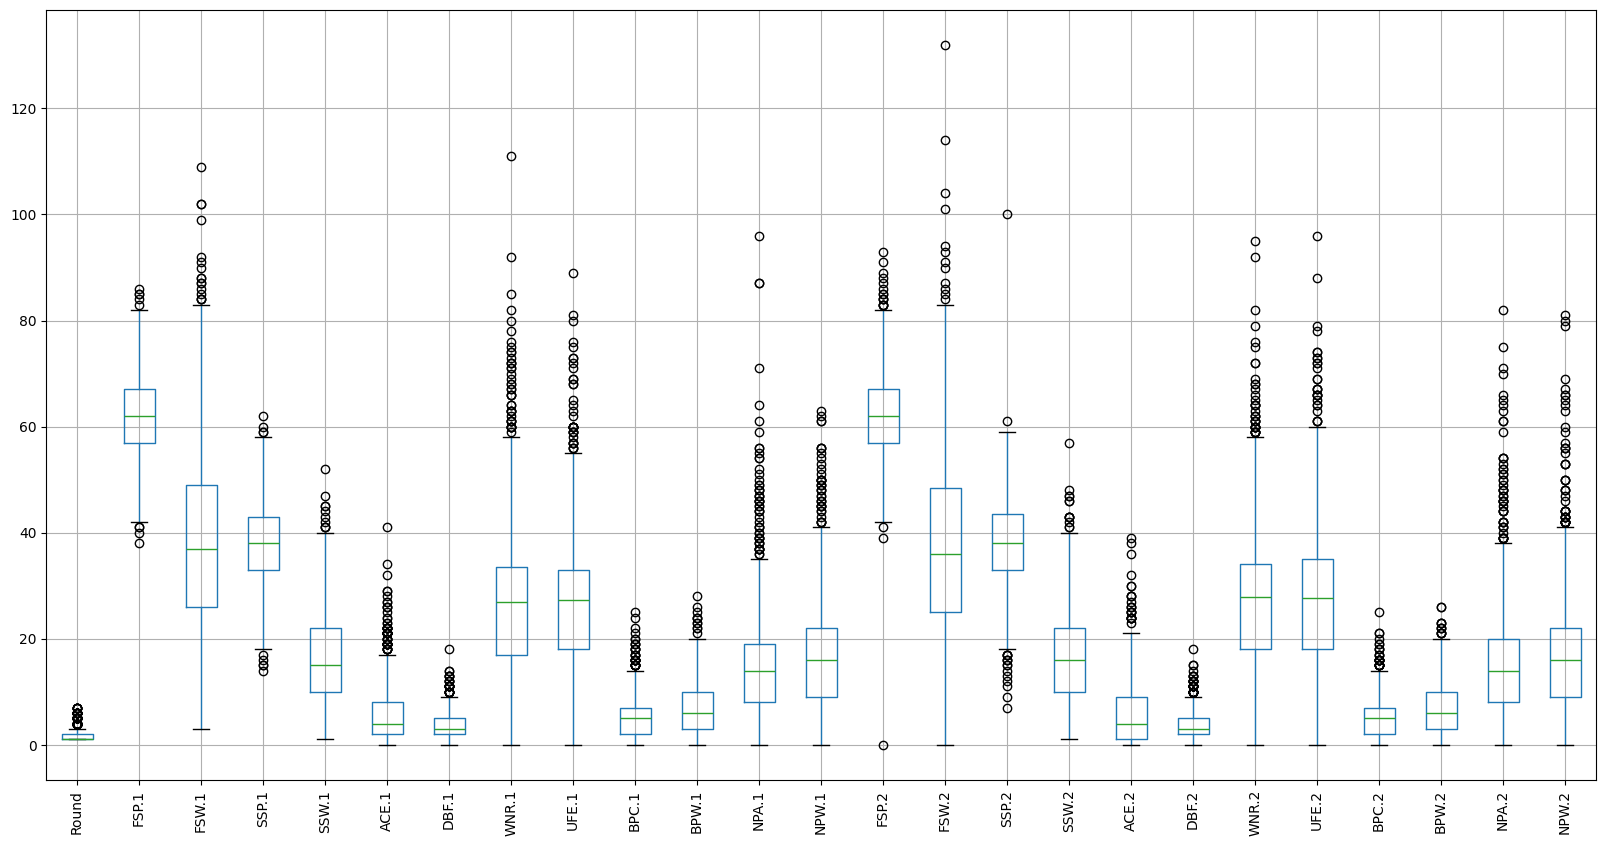

In [59]:
plt.figure(figsize=(20,10))
X.boxplot()
plt.xticks(rotation=90)
plt.show()

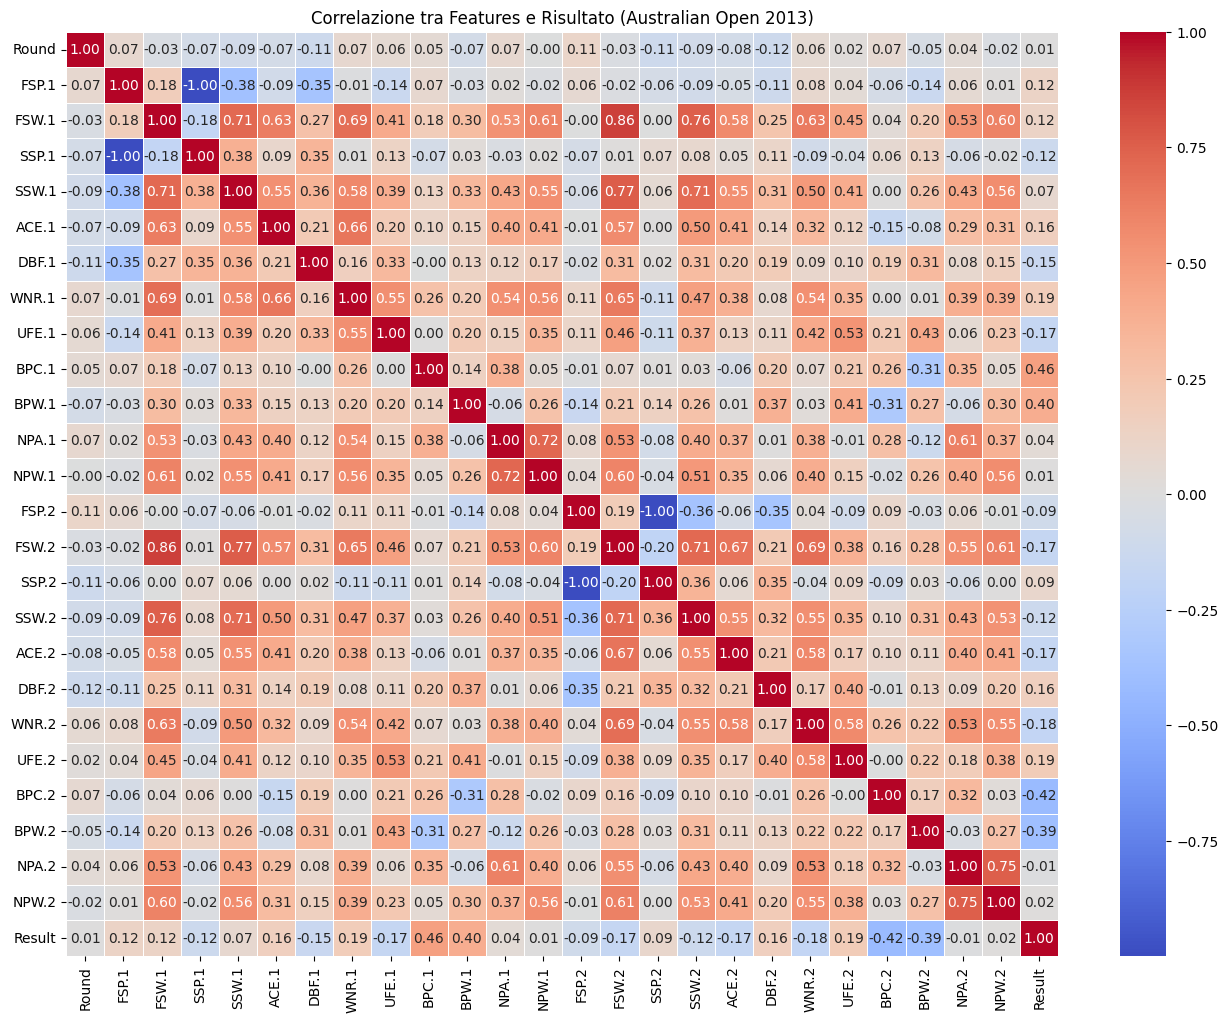

In [60]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Creiamo un DataFrame temporaneo che unisce X e y
# Questo serve per vedere la correlazione tra le statistiche e la vittoria
df_corr = X.copy()
df_corr['Result'] = y

# 2. Calcoliamo la matrice di correlazione
# Usiamo il metodo di Pearson (standard)
corr_matrix = df_corr.corr()

# 3. Visualizziamo la Heatmap
plt.figure(figsize=(16, 12)) # La facciamo grande per leggere bene i nomi
sns.heatmap(corr_matrix, 
            annot=True,      # Mostra i numeri dentro i quadratini
            fmt=".2f",       # Arrotonda a 2 decimali
            cmap='coolwarm', # Colore: rosso (positivo), blu (negativo)
            linewidths=0.5)

plt.title('Correlazione tra Features e Risultato (Australian Open 2013)')
plt.show()

In [61]:
corr_target = df_corr.corr()['Result'].sort_values(ascending=False)

print(corr_target)

Result    1.000000
BPC.1     0.462285
BPW.1     0.395337
UFE.2     0.192133
WNR.1     0.187556
ACE.1     0.161881
DBF.2     0.160631
FSP.1     0.121533
FSW.1     0.117916
SSP.2     0.094126
SSW.1     0.074887
NPA.1     0.043827
NPW.2     0.015697
Round     0.007591
NPW.1     0.007217
NPA.2    -0.011358
FSP.2    -0.094218
SSP.1    -0.118842
SSW.2    -0.121330
DBF.1    -0.145305
FSW.2    -0.167057
ACE.2    -0.169011
UFE.1    -0.169722
WNR.2    -0.181228
BPW.2    -0.390047
BPC.2    -0.424214
Name: Result, dtype: float64


In [62]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,   # 20% test
    stratify=y,      # mantiene proporzione classi
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (754, 25)
Test shape: (189, 25)


In [63]:
#adestramento Decision Tree

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

tree_model = DecisionTreeClassifier(random_state=42)

tree_model.fit(X_train, y_train)

y_pred = tree_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8941798941798942


[[84 12]
 [ 8 85]]


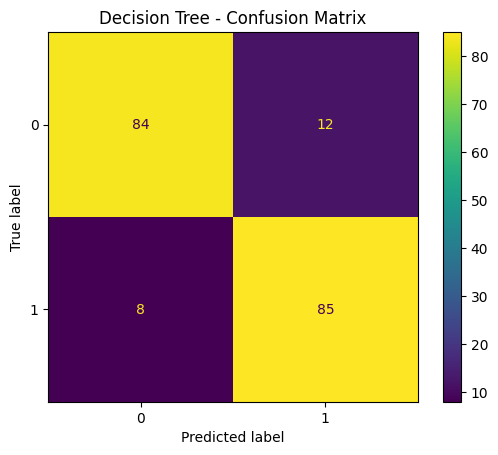

In [64]:
#confusion matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Decision Tree - Confusion Matrix")
plt.show()

In [65]:
# Classification Report (Precision, Recall, F1)

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.88      0.89        96
           1       0.88      0.91      0.89        93

    accuracy                           0.89       189
   macro avg       0.89      0.89      0.89       189
weighted avg       0.89      0.89      0.89       189



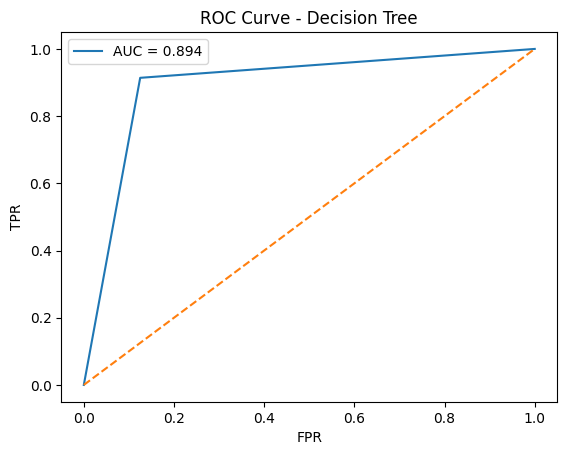

0.894489247311828


In [66]:
#ROC Curve e AUC - separazione generale

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_proba = tree_model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1],[0,1],"--")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve - Decision Tree")
plt.legend()
plt.show()
print(auc_score)

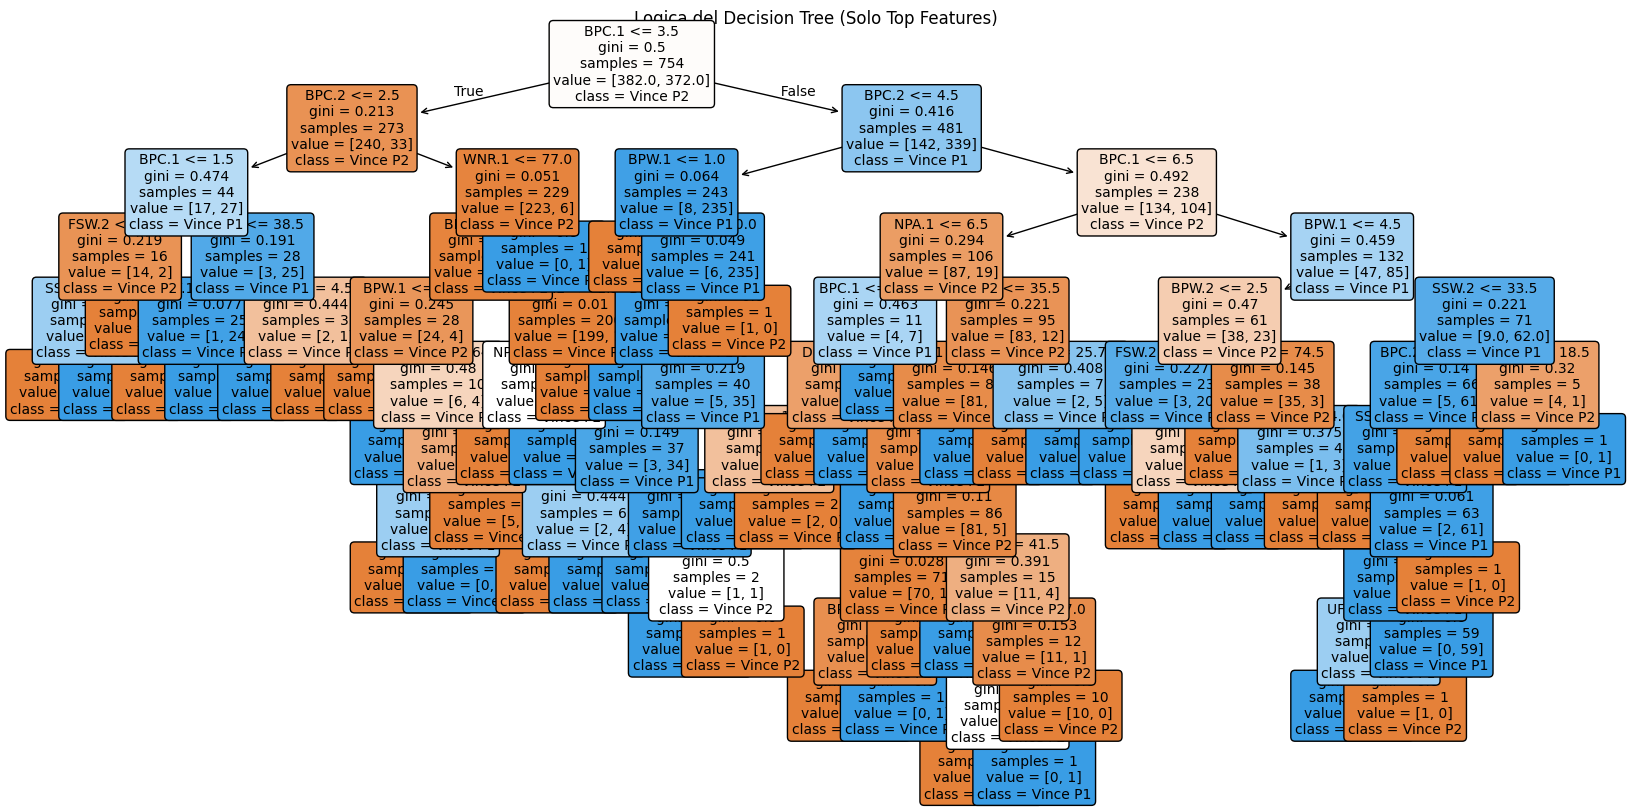

In [72]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
plt.figure(figsize=(20, 10))
plot_tree(tree_model,
          feature_names=X_train.columns,
          class_names=['Vince P2', 'Vince P1'],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Logica del Decision Tree")
plt.show()

In [68]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Random Forest
rf_model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

# Gradient Boosting
gb_model = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, random_state=42)
gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)
gb_proba = gb_model.predict_proba(X_test)[:, 1]

# Accuracy
print("Decision Tree:", accuracy_score(y_test, y_pred))
print("Random Forest:", accuracy_score(y_test, rf_pred))
print("Gradient Boosting:", accuracy_score(y_test, gb_pred))

# AUC
print("Tree AUC:", roc_auc_score(y_test, y_proba))
print("RF AUC:", roc_auc_score(y_test, rf_proba))
print("GB AUC:", roc_auc_score(y_test, gb_proba))



Decision Tree: 0.8941798941798942
Random Forest: 0.9312169312169312
Gradient Boosting: 0.9206349206349206
Tree AUC: 0.894489247311828
RF AUC: 0.9793346774193548
GB AUC: 0.979502688172043


In [69]:
import pandas as pd

importances = rf_model.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance_df)


   Feature  Importance
9    BPC.1    0.190999
21   BPC.2    0.168303
10   BPW.1    0.114312
22   BPW.2    0.098999
14   FSW.2    0.038376
2    FSW.1    0.037640
19   WNR.2    0.031536
20   UFE.2    0.029595
7    WNR.1    0.026427
4    SSW.1    0.024712
17   ACE.2    0.024654
8    UFE.1    0.024371
16   SSW.2    0.023252
5    ACE.1    0.021144
23   NPA.2    0.015351
11   NPA.1    0.014918
24   NPW.2    0.014827
3    SSP.1    0.014121
1    FSP.1    0.014102
18   DBF.2    0.013703
6    DBF.1    0.013419
13   FSP.2    0.013280
15   SSP.2    0.013197
12   NPW.1    0.013180
0    Round    0.005580


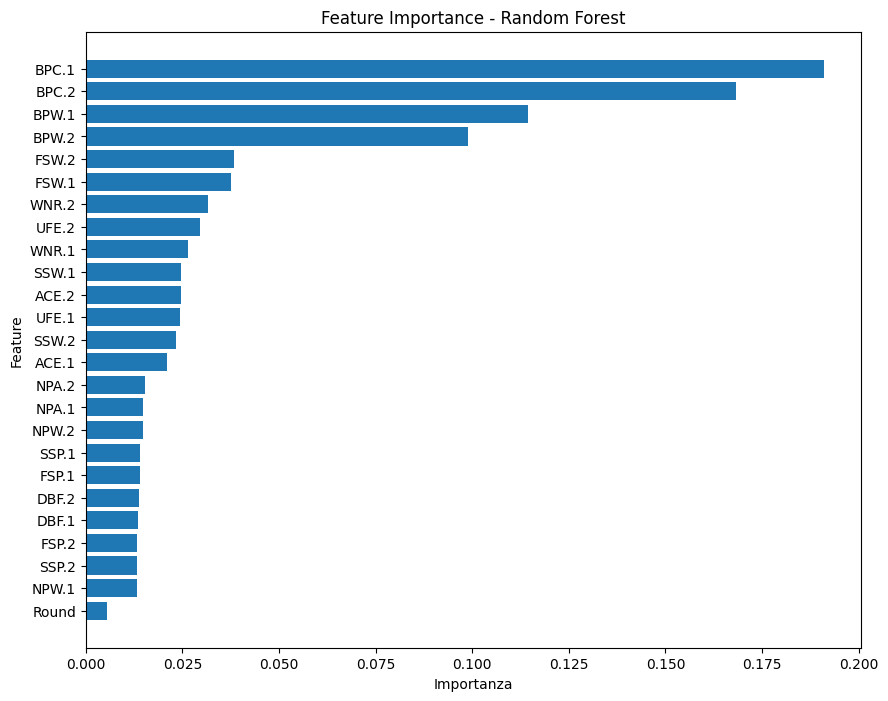

In [70]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

plt.barh(
    feature_importance_df["Feature"],
    feature_importance_df["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Feature Importance - Random Forest")
plt.xlabel("Importanza")
plt.ylabel("Feature")

plt.show()


In [74]:
from sklearn.model_selection import cross_val_score

tree_cv_scores = cross_val_score(
    tree_model,
    X_train,
    y_train,
    cv=5,
    scoring="roc_auc"
)

print("Tree CV AUC:", tree_cv_scores)
print("Media Tree:", tree_cv_scores.mean())


Tree CV AUC: [0.90078947 0.9004386  0.84801685 0.89452439 0.89366999]
Media Tree: 0.8874878596983861


In [75]:
rf_cv_scores = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=5,
    scoring="roc_auc"
)

print("RF CV AUC:", rf_cv_scores)
print("Media RF:", rf_cv_scores.mean())


RF CV AUC: [0.97517544 0.97973684 0.96762022 0.98587224 0.99039829]
Media RF: 0.979760605444816


In [76]:
gb_cv_scores = cross_val_score(
    gb_model,
    X_train,
    y_train,
    cv=5,
    scoring="roc_auc"
)

print("GB CV AUC:", gb_cv_scores)
print("Media GB:", gb_cv_scores.mean())


GB CV AUC: [0.97561404 0.97491228 0.95349245 0.98209898 0.97688478]
Media GB: 0.9726005061794535


In [77]:
print("\n=== CV AUC Media ===")

print(f"Decision Tree: {tree_cv_scores.mean():.3f}")
print(f"Random Forest: {rf_cv_scores.mean():.3f}")
print(f"Gradient Boosting: {gb_cv_scores.mean():.3f}")



=== CV AUC Media ===
Decision Tree: 0.887
Random Forest: 0.980
Gradient Boosting: 0.973


In [80]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score

# Pipeline
logistic_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic", LogisticRegression(max_iter=1000))
])

# Fit
logistic_pipeline.fit(X_train, y_train)

# Predict
log_pred = logistic_pipeline.predict(X_test)
log_proba = logistic_pipeline.predict_proba(X_test)[:, 1]

# Metriche
print("Logistic Accuracy:", accuracy_score(y_test, log_pred))
print("Logistic AUC:", roc_auc_score(y_test, log_proba))


Logistic Accuracy: 0.9365079365079365
Logistic AUC: 0.9859991039426523


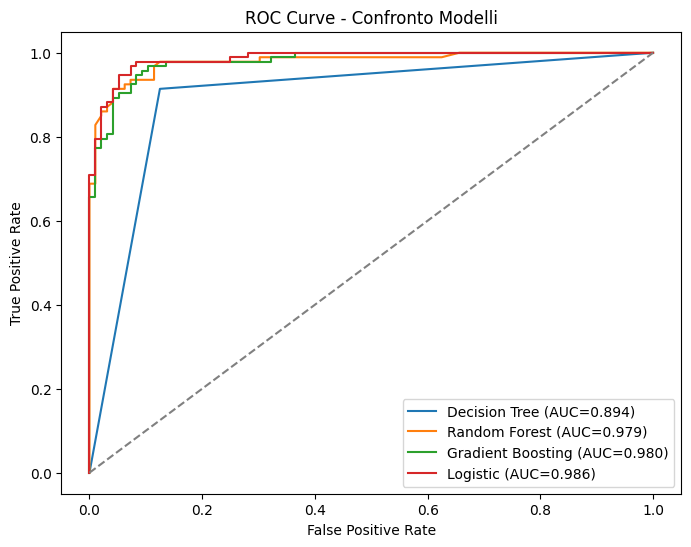

In [81]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Probabilità
tree_proba = tree_model.predict_proba(X_test)[:, 1]
rf_proba   = rf_model.predict_proba(X_test)[:, 1]
gb_proba   = gb_model.predict_proba(X_test)[:, 1]
log_proba  = logistic_pipeline.predict_proba(X_test)[:, 1]

# ROC curve
fpr_tree, tpr_tree, _ = roc_curve(y_test, tree_proba)
fpr_rf,   tpr_rf,   _ = roc_curve(y_test, rf_proba)
fpr_gb,   tpr_gb,   _ = roc_curve(y_test, gb_proba)
fpr_log, tpr_log,   _ = roc_curve(y_test, log_proba)


# AUC
auc_tree = roc_auc_score(y_test, tree_proba)
auc_rf   = roc_auc_score(y_test, rf_proba)
auc_gb   = roc_auc_score(y_test, gb_proba)
auc_log  = roc_auc_score(y_test, log_proba)


# Grafico
plt.figure(figsize=(8,6))

plt.plot(fpr_tree, tpr_tree,
         label=f"Decision Tree (AUC={auc_tree:.3f})")

plt.plot(fpr_rf, tpr_rf,
         label=f"Random Forest (AUC={auc_rf:.3f})")

plt.plot(fpr_gb, tpr_gb,
         label=f"Gradient Boosting (AUC={auc_gb:.3f})")

plt.plot(fpr_log, tpr_log,
         label=f"Logistic (AUC={auc_log:.3f})")

# linea casuale
plt.plot([0,1], [0,1], "--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Confronto Modelli")
plt.legend()

plt.show()

In [ ]:
    PR curve - focus sui positivi

Utile quando:
    classi sbilanciate
    interessa trovare i positivi
Nel tennis dataset non è critico, ma si studia lo stesso.

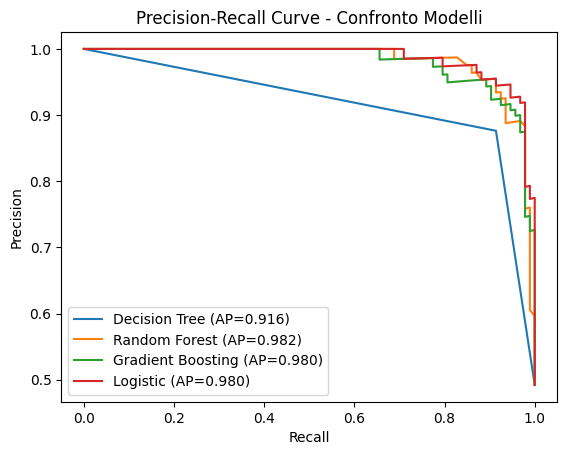

In [83]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

# Probabilità
tree_proba = tree_model.predict_proba(X_test)[:, 1]
rf_proba   = rf_model.predict_proba(X_test)[:, 1]
gb_proba   = gb_model.predict_proba(X_test)[:, 1]
log_proba  = logistic_pipeline.predict_proba(X_test)[:, 1]

# PR curve
precision_tree, recall_tree, _ = precision_recall_curve(y_test, tree_proba)
precision_rf, recall_rf, _     = precision_recall_curve(y_test, rf_proba)
precision_gb, recall_gb, _     = precision_recall_curve(y_test, gb_proba)
precision_log, recall_log, _  = precision_recall_curve(y_test, log_proba)

# AP
ap_tree = auc(recall_tree, precision_tree)
ap_rf   = auc(recall_rf, precision_rf)
ap_gb   = auc(recall_gb, precision_gb)
ap_log  = auc(recall_log, precision_log)

# Grafico
plt.figure()

plt.plot(recall_tree, precision_tree,
         label=f"Decision Tree (AP={ap_tree:.3f})")

plt.plot(recall_rf, precision_rf,
         label=f"Random Forest (AP={ap_rf:.3f})")

plt.plot(recall_gb, precision_gb,
         label=f"Gradient Boosting (AP={ap_gb:.3f})")

plt.plot(recall_log, precision_log,
         label=f"Logistic (AP={ap_gb:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Confronto Modelli")
plt.legend()

plt.show()


In [19]:
# versione con alcuni features che hanno maggior correlazione positiva e negativa con il target

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score

# --- 1. SELEZIONE TOP FEATURES ---
# Usiamo solo le variabili che la heatmap ci ha indicato come decisive
features_top = ['ACE.1', 'UFE.1', 'BPC.1', 'BPW.1', 'FSW.2', 'SSW.2', 'WNR.2', 'BPC.2', 'BPW.2']

# Creiamo il dataset filtrato
X_top = X[features_top].copy()


# --- 2. SPLIT DEI DATI ---
# Usiamo stratify=y come nel codice della tua collega per mantenere le proporzioni
X_train, X_test, y_train, y_test = train_test_split(
    X_top, y, 
    test_size=0.2, 
    stratify=y, 
    random_state=42
)

# --- 3. ADDESTRAMENTO DECISION TREE ---
# Usiamo max_depth=3 per evitare che l'albero diventi troppo complesso (overfitting)
tree_model_top = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_model_top.fit(X_train, y_train)

# --- 4. PREDIZIONE E VALUTAZIONE ---
y_pred = tree_model_top.predict(X_test)
y_proba = tree_model_top.predict_proba(X_test)[:, 1]

print(f"=== RISULTATI MODELLO TOP FEATURES ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))



=== RISULTATI MODELLO TOP FEATURES ===
Accuracy: 0.88

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.92      0.88        12
           1       0.92      0.86      0.89        14

    accuracy                           0.88        26
   macro avg       0.88      0.89      0.88        26
weighted avg       0.89      0.88      0.88        26



<Figure size 800x600 with 0 Axes>

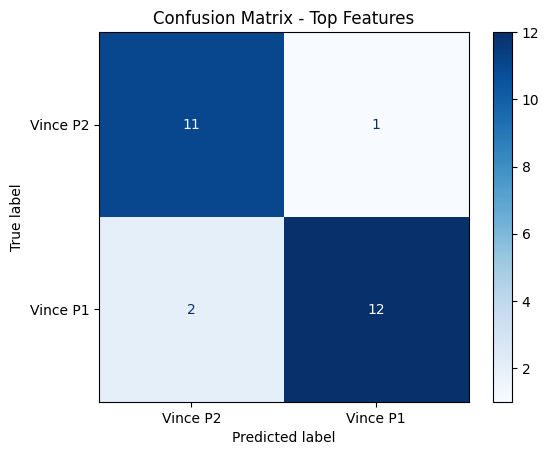

In [20]:
# --- 5. VISUALIZZAZIONE: CONFUSION MATRIX ---
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Vince P2', 'Vince P1'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Top Features")
plt.show()



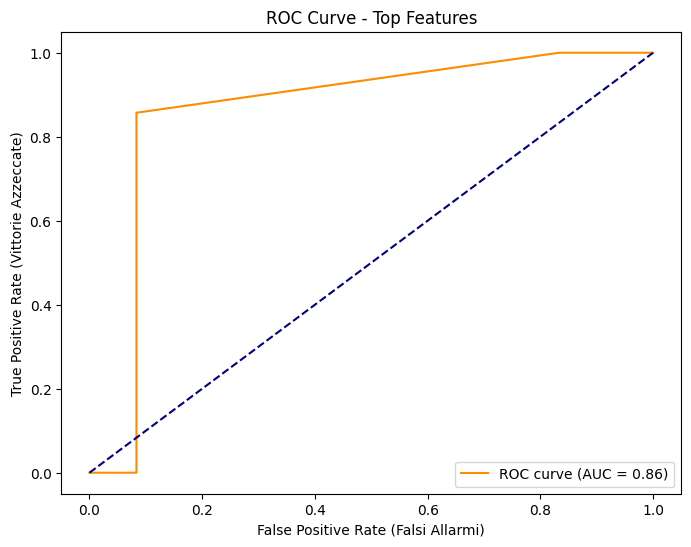

0.863095238095238


In [22]:
# --- 6. VISUALIZZAZIONE: CURVA ROC ---
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', label=f"ROC curve (AUC = {auc_score:.2f})")
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel("False Positive Rate (Falsi Allarmi)")
plt.ylabel("True Positive Rate (Vittorie Azzeccate)")
plt.title("ROC Curve - Top Features")
plt.legend(loc="lower right")
plt.show()
print(auc_score)


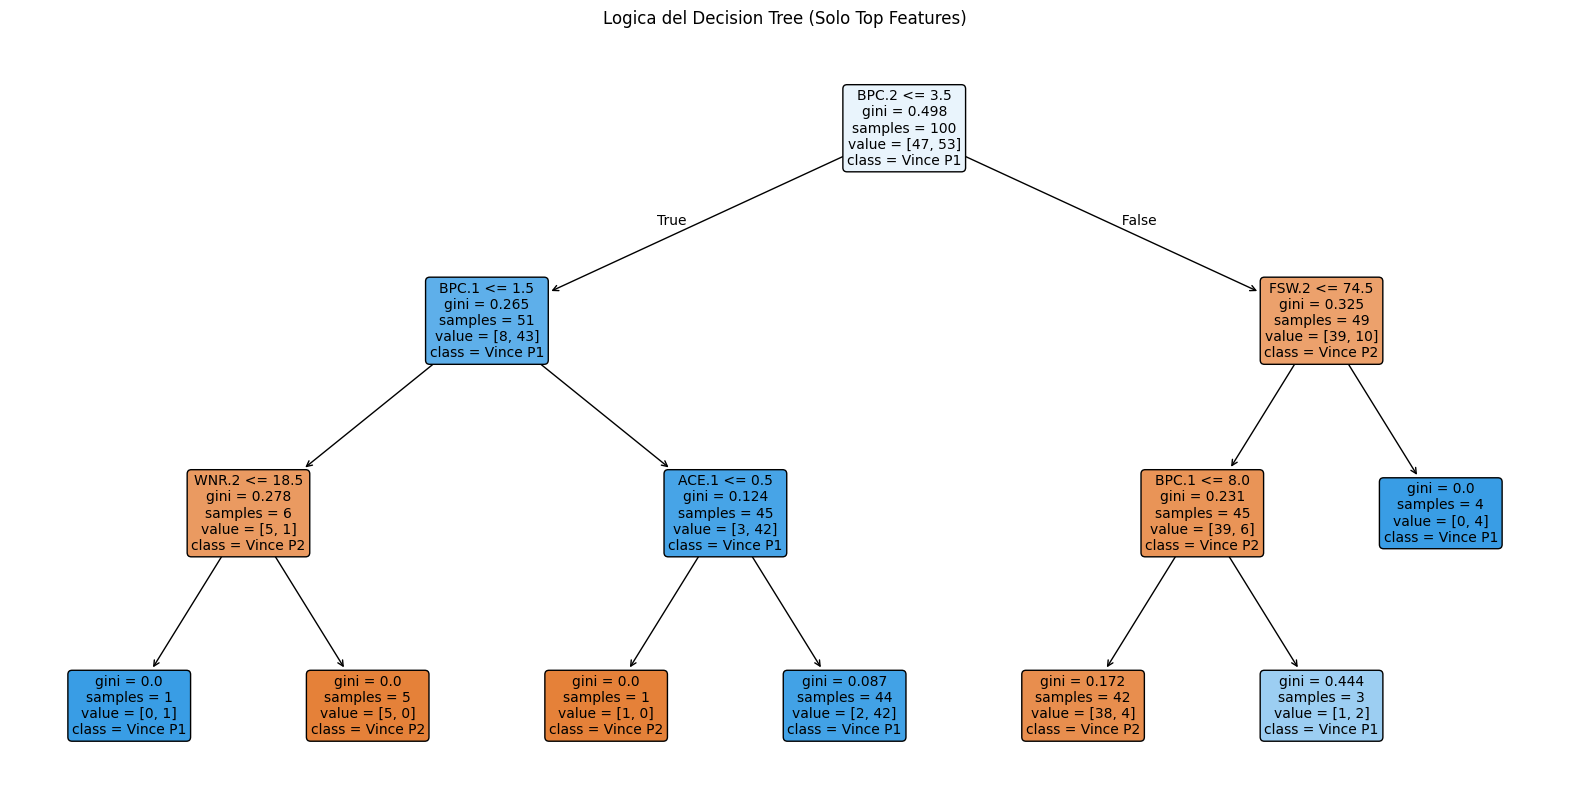

In [97]:
# --- 7. VISUALIZZAZIONE: L'ALBERO DECISIONALE ---
plt.figure(figsize=(20, 10))
plot_tree(tree_model_top, 
          feature_names=features_top, 
          class_names=['Vince P2', 'Vince P1'], 
          filled=True, 
          rounded=True, 
          fontsize=10)
plt.title("Logica del Decision Tree (Solo Top Features)")
plt.show()